## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [86]:
# 1
import numpy as np 
import pandas as pd 

df = pd.read_csv('data/golub.csv')
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [87]:
mapper = {'allB': 0, 'allT': 0, 'aml': 1}

df['cancer'] = df['cancer'].map(mapper)
df

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,0,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,0,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,0,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,0,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,0,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,29,BM,NaN,CALGB,BM:NA,1,-589.611534,-877.740714,-618.647808,-192.037937,...,-236.709128,475.796364,-502.502712,-4.418936,-652.151201,0.048183,-509.203391,-609.713570,4925.046956,-627.582046
68,30,BM,NaN,CALGB,BM:NA,1,-1552.764727,-1288.774596,-1085.544097,-232.814069,...,-415.092970,657.628835,-754.508853,102.411495,-817.363646,657.628835,-410.902650,-905.360357,-109.199643,-951.453872
69,31,BM,NaN,CALGB,BM:NA,1,-772.071972,-809.591203,-593.303872,-193.834414,...,-621.995048,605.104501,-575.647763,-226.939618,-750.001836,596.276447,95.284364,-758.829890,-407.914731,-772.071972
70,32,BM,NaN,CALGB,BM:NA,1,-1124.873709,-1026.849847,-935.360908,-135.921851,...,-96.712306,1188.489447,-887.438131,88.443879,-859.120126,1693.856917,-236.124022,-769.809496,-205.627709,-861.298435


Mean Squared Error: 8.708627224086994e-31


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  retur

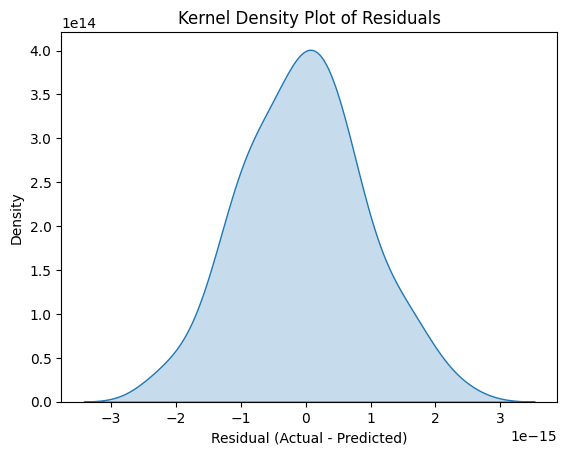

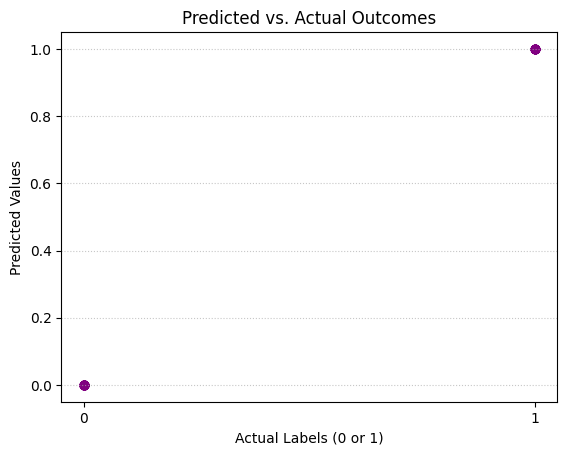

In [88]:
#2
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

X = df.drop(columns=['Samples', 'BM.PB', 'Gender', 'tissue.mf', 'cancer'])
X = X.select_dtypes(include=[np.number])
y = df['cancer']

model = LinearRegression(fit_intercept=True)
model.fit(X, y)

predictions = model.predict(X)
mse = mean_squared_error(y, predictions)
print(f"Mean Squared Error: {mse}")
residuals = y - predictions

sns.kdeplot(residuals, fill=True)
plt.title('Kernel Density Plot of Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Density')
plt.show()

plt.scatter(predictions, y, alpha=0.5, color="purple")
plt.title('Predicted vs. Actual Outcomes')
plt.xlabel('Actual Labels (0 or 1)')
plt.ylabel('Predicted Values')
plt.xticks([0, 1])
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

In [93]:
#3
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=10, scoring='neg_mean_squared_error')
cv_mse = -cv_scores.mean()

print(f"Cross-Validated Mean Squared Error: {cv_mse}")

# From the perspective of bias variance trade-off, we have very high variance and low bias.
# This is because we are overfitting by using all of the genes given to us. 
# We have minimized bias by adding too many parameters to the model, but we now have very high variance. 

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  retur

Cross-Validated Mean Squared Error: 0.06780005217137453


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
 

Optimal Alpha: 105.24436668425457
Genes Selected:
 HG3549-HT3751_at   -1.866398e-06
J04164_at          -2.975928e-06
L38941_at           9.359366e-07
M11147_at           9.651806e-07
M11722_at          -1.175811e-06
M17733_at          -3.027364e-06
M19507_at           1.150747e-05
M26602_at          -2.373871e-06
M27891_at           1.000528e-05
M33680_at          -1.070980e-06
M63138_at           1.294145e-05
M77232_rna1_at      4.205801e-07
M91036_rna1_at      2.704303e-06
M96326_rna1_at      3.045484e-06
U14968_at           1.377602e-06
X04500_at          -3.948526e-07
X17042_at           8.734762e-06
X78992_at           2.598685e-06
Z70759_at           1.289107e-06
L06797_s_at        -2.527830e-06
D49824_s_at        -1.121923e-07
M25079_s_at         4.082125e-07
X57351_s_at        -1.190599e-06
V00594_s_at        -1.685259e-06
U05255_s_at         1.146583e-05
X03689_s_at        -7.578508e-07
M14328_s_at         1.777423e-06
M14483_rna1_s_at   -1.758451e-06
M26708_s_at        -7.132

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  retur

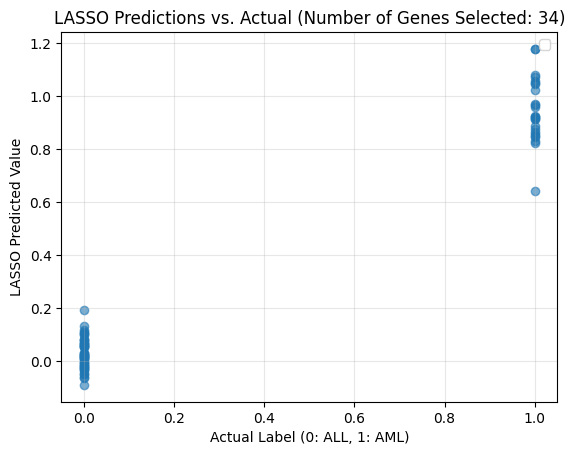

In [90]:
#4
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X, y)

coefs = pd.Series(lasso_cv.coef_, index=X.columns)
selected_genes = coefs[coefs != 0]
discarded_count = len(coefs) - len(selected_genes)

print(f"Optimal Alpha: {lasso_cv.alpha_}")
print(f"Genes Selected:\n {selected_genes}")
print(f"Number of Genes Selected: {len(selected_genes)}")
print(f"Number of Genes Discarded: {discarded_count}")

lasso_preds = lasso_cv.predict(X)
plt.scatter(y, lasso_preds, alpha=0.6)
plt.title(f'LASSO Predictions vs. Actual (Number of Genes Selected: {len(selected_genes)})')
plt.xlabel('Actual Label (0: ALL, 1: AML)')
plt.ylabel('LASSO Predicted Value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


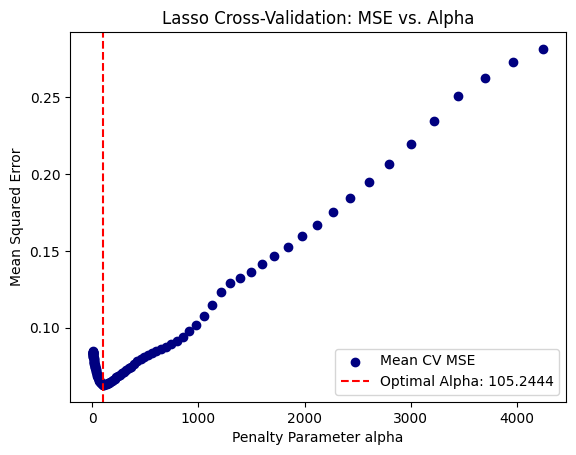

In [91]:
#5
lasso_cv = LassoCV(cv=5, random_state=556, max_iter=10000)
lasso_cv.fit(X, y)

alphas = lasso_cv.alphas_
mse_means = np.mean(lasso_cv.mse_path_, axis=1)
mse_stds = np.std(lasso_cv.mse_path_, axis=1)

plt.scatter(alphas, mse_means, label='Mean CV MSE', color='navy')
plt.axvline(lasso_cv.alpha_, linestyle='--', color='red', label=f'Optimal Alpha: {lasso_cv.alpha_:.4f}')

plt.xlabel('Penalty Parameter alpha')
plt.ylabel('Mean Squared Error')
plt.title('Lasso Cross-Validation: MSE vs. Alpha')
plt.legend()
plt.show()

# The LASSO is underfitting for the largest alphas, where the MSE is very high, to the right of the optimal alpha. 
# The LASSO is overfitting for the smallest alphas, where MSE is very low, to the left of the optimal alpha. 
# The optimal penality hyperparameter that minimizes expected MSE is 105.2444 (where the curve is minimized). 


6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

Linear regression performs perfectly on the training set because it can fit to all of the data points. There are over 7000 genes and only 72 observations, so the linear regression model can find a unique set of coefficients that pass exactly through every single training point. The model has essentially "memorized" the entire training set. 

However, LASSO has better predictions because it is much more generalizable. By forcing the coefficients of non-essential genes to zero, it ignores the "noise" and focuses only on the strongest biological signals. When shown a new patient, LASSO's more simplified logic generalizes better than the linear regression's over-complicated "memory."

7. Why do regularization methods lend themselves to scenarios like precision health? 

Regularization methods lend themselves to scenarios like precision health because it makes it a lot easier to handle "wide" data. With so many categories and only a few patients, there is a lot of overfitting without regularization methods like LASSO. 

LASSO acts as an automated filter. In a sea of these 7,000 genes, a doctor cannot act on all of them. Regularization identifies the 10 or 20 "highly predictive" genes that actually drive a disease, allowing for the development of targeted diagnostic tests or specific drug therapies.

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

One risk of applying methods like the Lasso to precision health questions where interventions will then be taken to optimize patient health is correlation versus causation. Lasso selects genes that are predictive, not necessarily causative. A gene might be selected by Lasso simply because it is highly correlated with the actual driver gene, but they may not actually be causing the health outcome, they may just be correlated. 

Another risk is that if two genes are highly correlated, Lasso will often randomly pick one and discard the other. This is bad because in a health setting, this means a doctor might ignore a vital gene that could be used to help patient health simply because another similar gene was chosen by the model.

A final risk is that by penalizing small coefficients, Lasso might discard a gene that has a very small but critical biological effect. In precision health, these "weak" signals can sometimes be the difference between a successful or failed intervention.
